# Q2 A/B Test: Car Ads With Leads

Assignment: evaluate how to test whether a new product feature increases the number of car ads with leads, and use the dataset to examine the test groups. A and B refer to the two test groups.

Primary KPI: Share of Car Ads With at Least One Lead.

`has_any_lead = telclicks > 0 OR bids > 0 OR n_asq > 0 OR webclicks > 0`

## 1. Recommended Test Setup

Use a randomized A/B test.

Why This Method:

- It is the cleanest way to estimate whether the feature caused a change in lead rate.
- Random assignment makes treatment and control ads more comparable.
- It is better than a before/after comparison, which can be affected by seasonality, buyer demand, or changes in ad supply.

Preferred Randomization Level: ad-level, assuming the feature affects individual ads and does not strongly change seller behavior across ads. If the feature is seller-side, seller-level randomization may be safer.

## 2. Risks and Challenges

Main Risks to Check Before Making a Causal Claim:

- Group assignment: confirm A is control and B is treatment.
- Randomization quality: groups should be balanced on key ad/car dimensions.
- Interference: treated ads may take leads from similar control ads.
- Logging quality: lead events should be tracked the same way in A and B.
- Missing groups: rows without group assignment should be reviewed.
- Guardrails: monitor lead quality, duplicate leads, seller quality, and buyer complaints.

In [1]:
from pathlib import Path
import sys
import importlib
import os
import tempfile

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "marketplaats-matplotlib"))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display

q2_dir = Path.cwd() / "assignments" / "data_analyst" / "q2_ab_test"
if not q2_dir.exists():
    q2_dir = Path.cwd()
if str(q2_dir) in sys.path:
    sys.path.remove(str(q2_dir))
sys.path.insert(0, str(q2_dir))

if "ab_test_helpers" in sys.modules:
    del sys.modules["ab_test_helpers"]
import ab_test_helpers as helpers
helpers = importlib.reload(helpers)

pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_columns", 80)
plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
PLOT_COLORS = {"A": "#4C78A8", "B": "#F58518", "diff": "#54A24B", "neutral": "#8A8F98"}


def finish_plot(ax, title, xlabel=None, ylabel=None, percent_x=False, percent_y=False):
    ax.set_title(title, loc="left", fontweight="bold", pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if percent_x:
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    if percent_y:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)
    return ax


def add_bar_labels(ax, percent=False, decimals=1, axis="vertical"):
    for patch in ax.patches:
        if axis == "vertical":
            value = patch.get_height()
            x = patch.get_x() + patch.get_width() / 2
            y = value
            label = f"{value:.{decimals}%}" if percent else f"{value:,.{decimals}f}"
            ax.annotate(label, (x, y), ha="center", va="bottom", xytext=(0, 4), textcoords="offset points", fontsize=9)
        else:
            value = patch.get_width()
            y = patch.get_y() + patch.get_height() / 2
            label = f"{value:.{decimals}%}" if percent else f"{value:,.{decimals}f}"
            if value < -0.025:
                x = value
                offset = 6
                ha = "left"
            else:
                x = value
                offset = 4 if value >= 0 else -4
                ha = "left" if value >= 0 else "right"
            ax.annotate(label, (x, y), ha=ha, va="center", xytext=(offset, 0), textcoords="offset points", fontsize=9)


def simplify_fully_labeled_bar_axis(ax, axis="vertical"):
    ax.grid(False)
    if axis == "vertical":
        ax.set_ylabel(None)
        ax.set_yticks([])
        ax.spines["left"].set_visible(False)
    else:
        ax.set_xlabel(None)
        ax.set_xticks([])
        ax.spines["bottom"].set_visible(False)


## 3. Data Checks

Basic Checks Before Comparing A and B.

In [3]:
raw_data = helpers.read_ab_test_data(helpers.DATA_PATH)
ab_data, excluded_data = helpers.prepare_ab_data(raw_data)
segmented_data = helpers.add_segments(ab_data)

print(f"Rows: {len(raw_data):,}")
print(f"Valid A/B rows: {len(ab_data):,}")
print(f"Rows dropped for missing group: {len(excluded_data):,} ({len(excluded_data) / len(raw_data):.2%})")

display(helpers.style_table(helpers.data_quality_checks(raw_data)))
display(helpers.style_table(helpers.undocumented_column_notes(raw_data)))
display(helpers.style_table(helpers.excluded_group_summary(raw_data, excluded_data)))
display(helpers.style_table(helpers.lead_metric_quality(raw_data)))

Rows: 183,062
Valid A/B rows: 174,449
Rows dropped for missing group: 8,613 (4.70%)


,Check,Value
0,Rows,"183,062"
1,Columns,22
2,Fully Duplicated Rows,0
3,Rows With Duplicated Ad ID,10
4,Unique Ad IDs,"183,057"


,Column,Note
0,Color,used as an optional car-color dimension
1,Mileage,used as an optional mileage dimension
2,Days Live,used as an optional ad-tenure dimension
3,L2,not used; meaning is unclear


,Metric,Rows,Row Share
0,Raw Rows,"183,062",1.000
1,Valid A/B Rows,"174,449",0.953
2,Missing-Group Rows,"8,613",0.047


,Metric,Missing Rows,Missing %,Negative Rows,Zero Rows,Max Value
0,Tel Clicks,9,0.000,0,"125,624",162
1,Bids,9,0.000,0,"152,145",124
2,Questions,0,0.000,0,"122,577",282
3,Web Clicks,9,0.000,0,"85,122",410


In [4]:
display(helpers.style_table(helpers.column_quality_summary(raw_data).query("missing_rows > 0"), max_rows=12))

,Column,Dtype,Missing Rows,Missing %,Unique
0,Energy Label,str,"49,384",0.270,7
1,Body Type,str,"17,851",0.098,8
2,Seats,Int64,"11,743",0.064,16
3,Test Group,str,"8,613",0.047,2
4,Doors,Int64,"5,375",0.029,9
5,Model,str,925,0.005,"2,447"
6,Emissions,Int64,191,0.001,356
7,Bids,Int64,9,0.000,42
8,Tel Clicks,Int64,9,0.000,65
9,Web Clicks,Int64,9,0.000,154


Notes:

- 4.7% of rows are dropped because `group` is missing.
- Lead metric columns (`telclicks`, `bids`, `n_asq`, `webclicks`) have at most 9 missing rows each, or 0.005% of the raw data. No negative values.
- Some fields are not in the documentation. I use clear car/ad dimensions where useful, but exclude `l2` because its meaning is unclear.

### Duplicated Ad IDs

There are 5 duplicated `src_ad_id` values, covering 10 rows.

In [5]:
display(helpers.style_table(helpers.duplicated_ad_id_rows(raw_data)))

,Ad ID,Tel Clicks,Bids,Body Type,Photos,Doors,Questions,Build Year,Emissions,Energy Label,Brand,Start Date,Power,Web Clicks,Model,Seats,Price,Test Group
0,1011548826,0,0,MPV,18,5,0,2003,152,D,RENAULT,2016-11-25,59,1,Scenic,5,"22,500",A
1,1011548826,0,0,Hatchback (3/5-deurs),14,4,0,2005,169,C,CITROEN,2016-11-25,80,0,C4,5,"52,500",B
2,1027581466,0,0,Hatchback (3/5-deurs),13,5,0,2010,0,NaN,SEAT,2016-11-06,118,2,Leon,5,"117,500",A
3,1027581466,0,0,MPV,24,4,0,2008,155,C,MERCEDES,2016-11-06,70,0,A-Klasse,5,"79,500",B
4,1045227572,0,0,Hatchback (3/5-deurs),24,5,0,2012,134,C,OPEL,2016-11-26,74,0,CORSA,5,"89,500",A
5,1045227572,0,0,Terreinwagen,24,5,0,2013,168,D,MINI,2016-11-26,90,1,Countryman,5,"269,500",B
6,1054003502,0,0,Stationwagon,24,5,0,2005,235,F,SAAB,2016-11-19,154,2,3-Sep,5,"64,000",A
7,1054003502,1,0,Sedan (2/4-deurs),11,4,0,2006,186,C,AUDI,2016-11-19,103,2,A6,5,"73,900",A
8,1072325510,0,0,Hatchback (3/5-deurs),12,3,0,2013,92,A,FIAT,2016-11-07,63,0,500,4,"99,450",A
9,1072325510,0,0,Cabriolet,24,2,0,2000,294,NaN,CHEVROLET,2016-11-07,142,3,Camaro,4,"119,000",B


In [6]:
display(helpers.style_table(helpers.duplicated_ad_id_differences(raw_data)))

,Ad ID,Rows,Groups Seen,Varying Columns
0,1011548826,2,"A, B","carrosserie, photo_cnt, aantaldeuren, bouwjaar, emissie, energielabel, brand, vermogen, webclicks, model, price, group"
1,1027581466,2,"A, B","carrosserie, photo_cnt, aantaldeuren, bouwjaar, emissie, energielabel, brand, vermogen, webclicks, model, price, group"
2,1045227572,2,"A, B","carrosserie, bouwjaar, emissie, energielabel, brand, vermogen, webclicks, model, price, group"
3,1054003502,2,A,"telclicks, carrosserie, photo_cnt, aantaldeuren, bouwjaar, emissie, energielabel, brand, vermogen, model, price"
4,1072325510,2,"A, B","carrosserie, photo_cnt, aantaldeuren, bouwjaar, emissie, energielabel, brand, vermogen, webclicks, model, price, group"


Likely ID quality issue. The paired rows differ on car attributes. Kept in the main analysis; sensitivity excludes them.

## 4. A/B Balance

Check test-group size and main car dimensions. Difference and % Diff are B minus A.

In [7]:
display(helpers.style_table(helpers.group_size_summary(ab_data)))
display(helpers.style_table(helpers.numeric_balance_summary(ab_data)))

,Test Group,Rows,Row Share
0,A,"94,281",0.540
1,B,"80,168",0.460


group,Dimension,A,B,Diff B-A,% Diff
0,Price,"106,457.104","95,563.256","-10,893.849",-0.102
1,Mileage,"140,764.544","149,516.859","8,752.315",0.062
2,Days Live,27.624,27.646,0.022,0.001
3,Photos,15.742,15.366,-0.376,-0.024
4,Build Year,2007.560,2006.721,-0.839,-0.000
5,Doors,4.270,4.220,-0.049,-0.012
6,Seats,4.735,4.747,0.012,0.002
7,Emissions,129.123,129.950,0.827,0.006
8,Power,85.787,85.420,-0.367,-0.004
9,Car Age,8.440,9.279,0.839,0.099


### Balance Visuals

TL;DR: there are two different balance issues. First, B has fewer records than A, which mainly reduces statistical power and should trigger a sample-ratio check. Second, B records differ from A on key car/ad dimensions such as price, mileage, and age; that is the more important causal-validity concern because it may mean the groups are not comparable. A well-designed test should address both upfront through clean randomization, pre-defined exclusion rules, sample-ratio monitoring, and potentially stratified/block randomization on important dimensions.

#### A/B-Assigned Records by Group

Main narrative: B has fewer records than A. By itself, this does not imply the groups are compositionally imbalanced; it mostly reduces statistical power because the smaller group limits precision. The practical implication is to run a sample-ratio mismatch check and review whether assignment or exclusions created the uneven split.

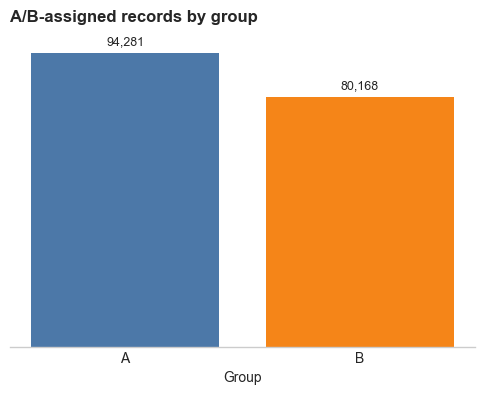

In [8]:
group_sizes = helpers.group_size_summary(ab_data).copy()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(group_sizes["group"], group_sizes["rows"], color=[PLOT_COLORS.get(group, PLOT_COLORS["neutral"]) for group in group_sizes["group"]])
finish_plot(ax, "A/B-assigned records by group", xlabel="Group", ylabel="Records")
add_bar_labels(ax, decimals=0)
simplify_fully_labeled_bar_axis(ax)
plt.show()


#### Numeric Balance: B vs A

Main narrative: B differs from A on several car/ad dimensions, especially price, mileage, and car age. Unlike the record-count imbalance, this does affect group comparability. The practical implication is stronger: if these differences came from imperfect randomization, filtering, or exposure rules, part of the lead-rate difference could reflect group composition rather than the feature itself. This should be accounted for in test design, ideally before launch.

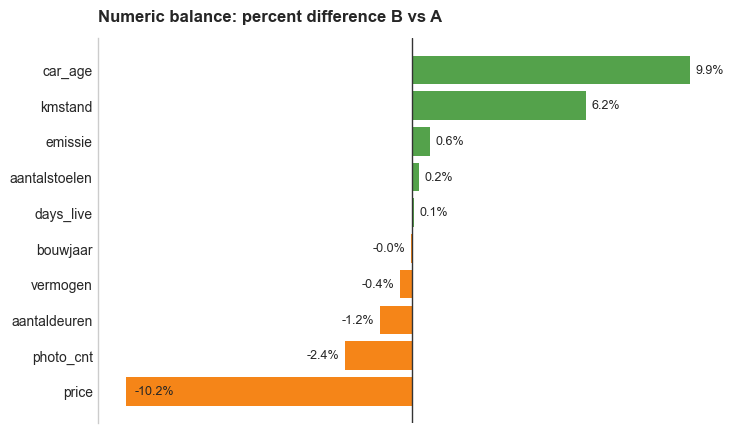

In [9]:
numeric_balance = helpers.numeric_balance_summary(ab_data).dropna(subset=["pct_diff_vs_A"]).copy()
numeric_balance = numeric_balance.sort_values("pct_diff_vs_A")
fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = [PLOT_COLORS["diff"] if value >= 0 else PLOT_COLORS["B"] for value in numeric_balance["pct_diff_vs_A"]]
ax.barh(numeric_balance["dimension"], numeric_balance["pct_diff_vs_A"], color=bar_colors)
ax.axvline(0, color="#333333", linewidth=1)
finish_plot(ax, "Numeric balance: percent difference B vs A", xlabel="Percent difference", ylabel=None, percent_x=True)
add_bar_labels(ax, percent=True, decimals=1, axis="horizontal")
simplify_fully_labeled_bar_axis(ax, axis="horizontal")
plt.show()


B has fewer ads. B cars are also cheaper, higher mileage, and older on average. This limits causal interpretation unless randomization is confirmed.

## 5. Result

Primary Readout: Share of Ads With at Least One Lead. Lead rate means the share of ads with at least one lead.

In [10]:
display(helpers.style_table(helpers.lead_outcome_summary(ab_data)))
display(helpers.style_table(helpers.lead_rate_lift(ab_data)))
display(helpers.style_table(helpers.duplicate_id_sensitivity(ab_data)))

,Test Group,Ads,Ads With Leads,Lead Rate,Avg Leads/Ad,Median Leads/Ad,Avg Tel Clicks,Avg Bids,Avg Questions,Avg Web Clicks
0,A,"94,281","68,653",0.728,5.151,2.000,0.873,0.647,0.942,2.688
1,B,"80,168","59,999",0.748,5.510,2.000,0.967,0.712,1.041,2.790


,Metric,Value
0,A Lead Rate,0.728
1,B Lead Rate,0.748
2,B-A Lead Rate Diff,0.020
3,Relative Lift vs A,0.028
4,Approx. 95% CI lower for difference,0.016
5,Approx. 95% CI upper for difference,0.024


,Metric,With Dup IDs,Excl Dup IDs
0,Rows,"174,449","174,439"
1,Rows Dropped,0,10
2,% Rows Dropped,0,0.000
3,A Lead Rate,0.728,0.728
4,B Lead Rate,0.748,0.748
5,B-A Lead Rate Diff,0.020,0.020
6,Relative Lift vs A,0.028,0.028


### Result Visuals

TL;DR: B outperforms A on the primary lead-rate KPI and also has higher average lead volume per ad. The distribution and duplicate-ID checks are diagnostics: they test whether the result is overly driven by outliers or by duplicated ad IDs. Neither diagnostic changes the main readout.

#### Primary KPI: Share of Ads With at Least One Lead

Main narrative: B has a higher share of ads receiving at least one lead than A. This is the cleanest visual for the assignment's primary question because it compares the exact KPI directly between the two groups.

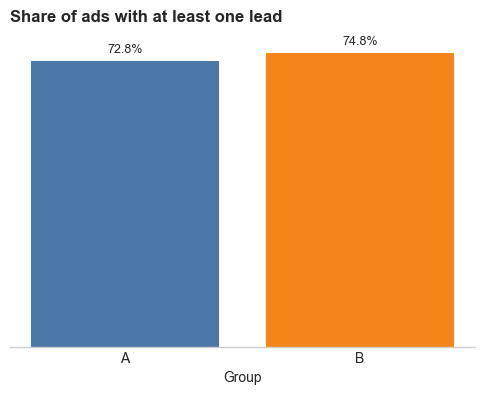

In [11]:
outcomes = helpers.lead_outcome_summary(ab_data)
lift = helpers.lead_rate_lift(ab_data).set_index("metric")["value"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(outcomes["group"], outcomes["lead_rate"], color=[PLOT_COLORS.get(group, PLOT_COLORS["neutral"]) for group in outcomes["group"]])
finish_plot(ax, "Share of ads with at least one lead", xlabel="Group", ylabel="Lead rate", percent_y=True)
add_bar_labels(ax, percent=True, decimals=1)
simplify_fully_labeled_bar_axis(ax)
plt.show()


#### Average Leads per Ad by Channel

Main narrative: B is higher not only on the binary lead-rate KPI, but also on average lead volume. The channel split shows where that higher volume comes from and checks whether the total-leads improvement is concentrated in a single lead type.

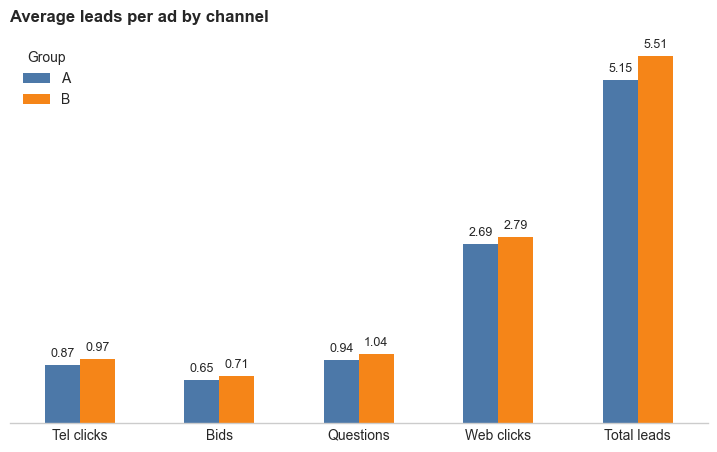

In [12]:
channel_columns = ["avg_telclicks", "avg_bids", "avg_questions", "avg_webclicks", "avg_total_leads"]
channel_labels = ["Tel clicks", "Bids", "Questions", "Web clicks", "Total leads"]
channel_plot = outcomes.set_index("group")[channel_columns].T
channel_plot.index = channel_labels
fig, ax = plt.subplots(figsize=(9, 5))
channel_plot.plot(kind="bar", ax=ax, color=[PLOT_COLORS["A"], PLOT_COLORS["B"]])
finish_plot(ax, "Average leads per ad by channel", xlabel=None, ylabel="Average per ad")
add_bar_labels(ax, decimals=2)
simplify_fully_labeled_bar_axis(ax)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Group", frameon=False)
plt.show()


#### Total Leads per Ad Distribution

Purpose: this is a diagnostic plot, not the primary result. It checks whether B's higher average total leads is visible across the common range of ads or mainly caused by a small number of extreme high-lead ads. The distribution is very skewed, so values are clipped at p99 and A/B are shown in separate panels with the same scale.

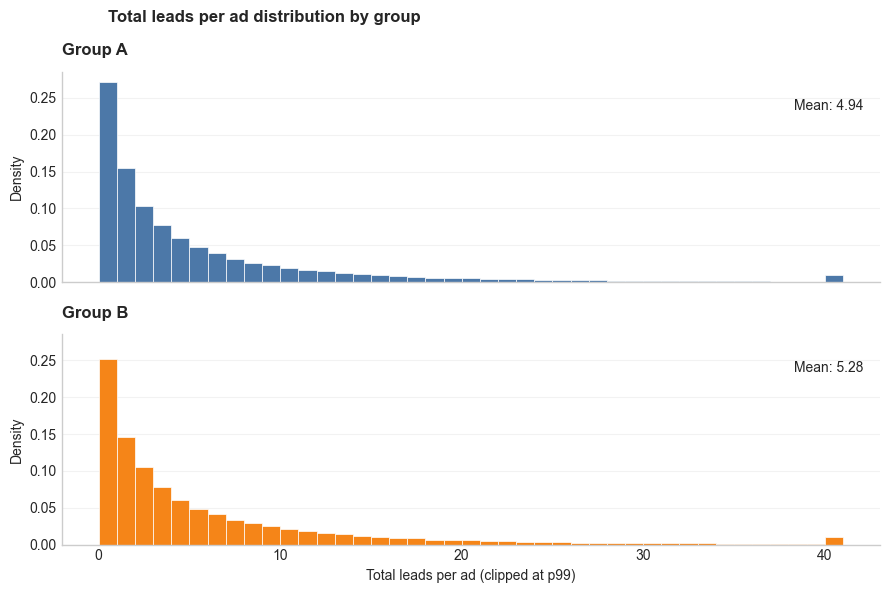

In [13]:
clip_at = ab_data["total_leads"].quantile(0.99)
bins = range(0, int(clip_at) + 2)
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True, sharey=True)
for ax, group in zip(axes, ["A", "B"]):
    group_data = ab_data.loc[ab_data["group"] == group, "total_leads"].clip(upper=clip_at)
    ax.hist(group_data, bins=bins, density=True, color=PLOT_COLORS[group], edgecolor="white", linewidth=0.5)
    finish_plot(ax, f"Group {group}", xlabel=None, ylabel="Density")
    ax.text(0.98, 0.82, f"Mean: {group_data.mean():.2f}", transform=ax.transAxes, ha="right", fontsize=10)
axes[-1].set_xlabel("Total leads per ad (clipped at p99)")
fig.suptitle("Total leads per ad distribution by group", x=0.125, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()


#### Duplicate-ID Sensitivity

Purpose: this is a robustness check. It asks whether the main lead-rate comparison changes after excluding duplicated `src_ad_id` rows. The chart shows the answer is effectively no: the A and B rates are stable with or without those rows.

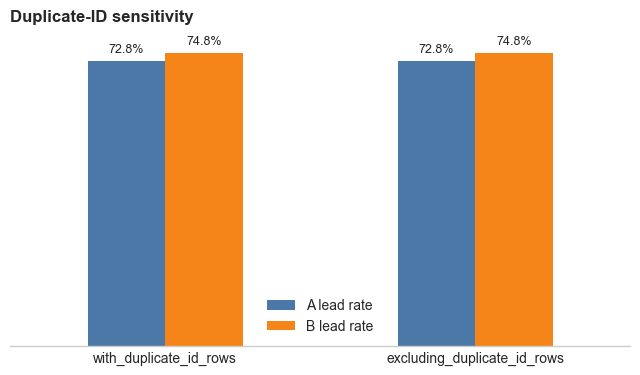

In [14]:
sensitivity = helpers.duplicate_id_sensitivity(ab_data).set_index("metric").loc[["A lead rate", "B lead rate"]]
fig, ax = plt.subplots(figsize=(8, 4))
sensitivity.T.plot(kind="bar", ax=ax, color=[PLOT_COLORS["A"], PLOT_COLORS["B"]])
finish_plot(ax, "Duplicate-ID sensitivity", xlabel=None, ylabel="Lead rate", percent_y=True)
add_bar_labels(ax, percent=True, decimals=1)
simplify_fully_labeled_bar_axis(ax)
ax.tick_params(axis="x", rotation=0)
ax.legend(title=None, frameon=False)
plt.show()


Result:

- A lead rate: 72.82%
- B lead rate: 74.84%
- Difference: +2.02 pp
- Relative lift: +2.78%
- Average total leads: 5.15 in A vs 5.51 in B

Dropping duplicated-ID rows removes 10 rows, or 0.006% of valid A/B rows, and does not alter the outcome.

## 6. Segment Checks

Segment cuts are diagnostic only. Price and mileage use fixed, rounded bands for readability rather than quartile-based cutoffs. Lead rate means the share of ads with at least one lead. Diff and relative lift are B minus A. Dropped rows are rows that cannot be assigned to a band, usually because the source value is missing.

In [15]:
segment_columns = ["price_band", "km_band", "car_age_band"]
display(helpers.style_table(helpers.segment_coverage_summary(segmented_data, segment_columns)))
display(helpers.style_table(helpers.segment_outcome_summary(segmented_data, "price_band")))
display(helpers.style_table(helpers.segment_outcome_summary(segmented_data, "km_band")))
display(helpers.style_table(helpers.segment_outcome_summary(segmented_data, "car_age_band")))
display(helpers.style_table(helpers.top_category_segment_summary(ab_data, "brand")))

,Segment,Source Column,Rows Used,Rows Dropped,Missing Source,Out of Band,% Rows Dropped
0,Price Band,Price,"174,443",6,6,0,0.000
1,Mileage Band,Mileage,"173,112","1,337","1,337",0,0.008
2,Car Age Band,Car Age,"174,449",0,0,0,0.000


,Price Band,Ad Count A,Ad Count B,Lead Rate A,Lead Rate B,Avg Leads/Ad A,Avg Leads/Ad B,Lead Rate Diff,Rel Lift,Small Segment
0,0-25k,"25,086","24,742",0.884,0.886,8.702,8.672,0.001,0.001,False
1,25k-60k,"21,301","18,979",0.797,0.801,5.751,5.837,0.004,0.006,False
2,60k-120k,"23,041","18,188",0.660,0.669,3.451,3.608,0.009,0.013,False
3,120k+,"24,849","18,257",0.575,0.587,2.627,2.780,0.012,0.021,False


,Mileage Band,Ad Count A,Ad Count B,Lead Rate A,Lead Rate B,Avg Leads/Ad A,Avg Leads/Ad B,Lead Rate Diff,Rel Lift,Small Segment
0,0-75k,"24,222","17,899",0.517,0.532,2.447,2.621,0.015,0.029,False
1,75k-150k,"29,490","24,272",0.744,0.751,5.001,5.240,0.007,0.010,False
2,150k-200k,"17,814","16,325",0.821,0.829,6.451,6.699,0.008,0.009,False
3,200k+,"22,067","21,023",0.858,0.862,7.098,7.229,0.004,0.005,False


,Car Age Band,Ad Count A,Ad Count B,Lead Rate A,Lead Rate B,Avg Leads/Ad A,Avg Leads/Ad B,Lead Rate Diff,Rel Lift,Small Segment
0,0-3,"19,307","13,345",0.472,0.466,1.808,1.696,-0.006,-0.012,False
1,4-7,"24,682","19,036",0.693,0.695,3.887,3.962,0.002,0.003,False
2,8-12,"26,590","23,446",0.813,0.818,6.160,6.186,0.005,0.007,False
3,13+,"23,702","24,341",0.878,0.877,8.056,8.160,-0.001,-0.001,False


,Brand,Ad Count A,Ad Count B,Lead Rate A,Lead Rate B,Avg Leads/Ad A,Avg Leads/Ad B,Lead Rate Diff,Rel Lift,Small Segment
0,BMW,"4,804","4,011",0.790,0.815,6.747,7.111,0.025,0.031,False
1,CITROEN,"4,432","3,670",0.671,0.684,4.030,4.263,0.013,0.020,False
2,FORD,"6,964","5,720",0.660,0.679,4.163,4.402,0.019,0.029,False
3,MERCEDES,"3,965","3,492",0.782,0.814,6.337,6.701,0.032,0.041,False
4,OPEL,"7,674","6,673",0.735,0.750,5.219,5.450,0.015,0.020,False
5,PEUGEOT,"7,967","6,847",0.632,0.659,4.130,4.521,0.027,0.042,False
6,RENAULT,"7,717","6,590",0.695,0.723,4.150,4.743,0.028,0.040,False
7,VOLKSWAGEN,"11,464","9,632",0.797,0.811,6.671,7.057,0.014,0.017,False


### Segment Visuals

Use line charts to compare A and B lead rates within ordered bands, and a horizontal bar chart to show which top brands have the largest B-minus-A lift.

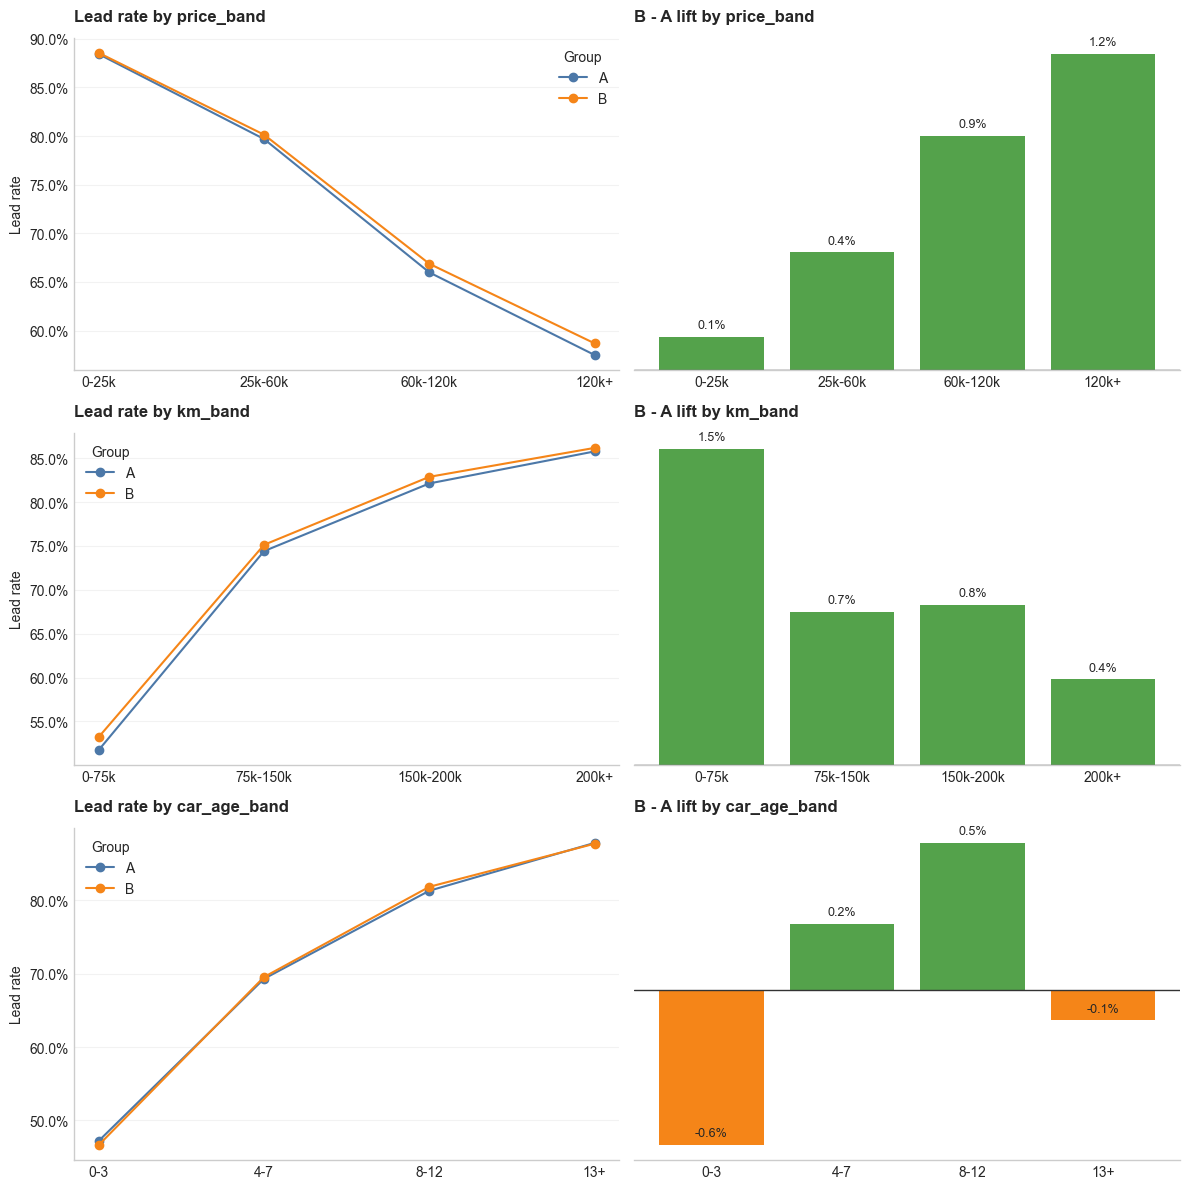

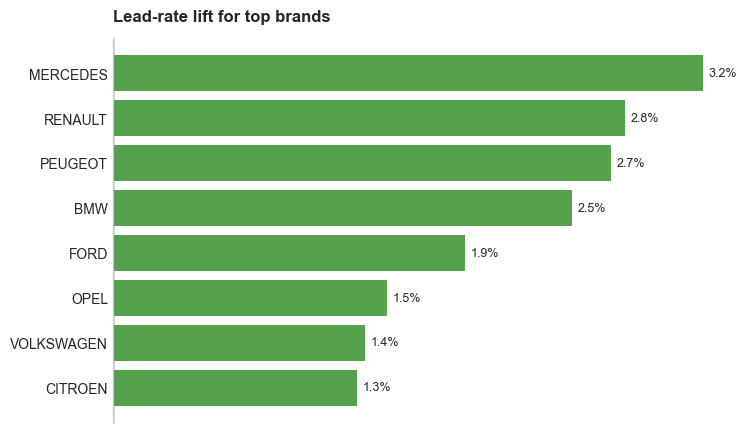

In [16]:
fig, axes = plt.subplots(len(segment_columns), 2, figsize=(12, 4 * len(segment_columns)))
for row_index, segment_column in enumerate(segment_columns):
    summary = helpers.segment_outcome_summary(segmented_data, segment_column)
    labels = summary[segment_column].astype(str)

    ax_rate = axes[row_index, 0]
    ax_rate.plot(labels, summary["lead_rate_A"], marker="o", color=PLOT_COLORS["A"], label="A")
    ax_rate.plot(labels, summary["lead_rate_B"], marker="o", color=PLOT_COLORS["B"], label="B")
    finish_plot(ax_rate, f"Lead rate by {segment_column}", xlabel=None, ylabel="Lead rate", percent_y=True)
    ax_rate.legend(title="Group", frameon=False)

    ax_diff = axes[row_index, 1]
    colors = [PLOT_COLORS["diff"] if value >= 0 else PLOT_COLORS["B"] for value in summary["lead_rate_diff_B_minus_A"]]
    ax_diff.bar(labels, summary["lead_rate_diff_B_minus_A"], color=colors)
    ax_diff.axhline(0, color="#333333", linewidth=1)
    finish_plot(ax_diff, f"B - A lift by {segment_column}", xlabel=None, ylabel="Lead-rate difference", percent_y=True)
    add_bar_labels(ax_diff, percent=True, decimals=1)
    simplify_fully_labeled_bar_axis(ax_diff)

plt.tight_layout()
plt.show()

brand_summary = helpers.top_category_segment_summary(ab_data, "brand").sort_values("lead_rate_diff_B_minus_A")
fig, ax = plt.subplots(figsize=(8, 5))
colors = [PLOT_COLORS["diff"] if value >= 0 else PLOT_COLORS["B"] for value in brand_summary["lead_rate_diff_B_minus_A"]]
ax.barh(brand_summary["brand"], brand_summary["lead_rate_diff_B_minus_A"], color=colors)
ax.axvline(0, color="#333333", linewidth=1)
finish_plot(ax, "Lead-rate lift for top brands", xlabel="B - A lead-rate difference", ylabel=None, percent_x=True)
add_bar_labels(ax, percent=True, decimals=1, axis="horizontal")
simplify_fully_labeled_bar_axis(ax, axis="horizontal")
plt.show()


Segment Read:

- B is higher across price and mileage bands.
- Car-age results are mixed.
- Most top brands show a positive B lift.
- These are pattern checks, not subgroup causal claims.

## 7. Business Answer

In [17]:
helpers.print_business_insights(ab_data)

- Primary Outcome: B has a 2.02% higher share of ads with any lead than A (2.78% relative lift).
- Lead Volume: B also has higher average total leads per ad (5.510 vs 5.151).
- Group Balance: The largest average numeric balance gap is price (-10.23% B vs A).
- Interpretation: The result is directionally positive, but should be framed as causal only after confirming the assignment process and exposure logging.


### Business Summary Visual

Use a compact KPI chart to keep the final business answer anchored in the two headline comparisons: lead rate and average total leads.

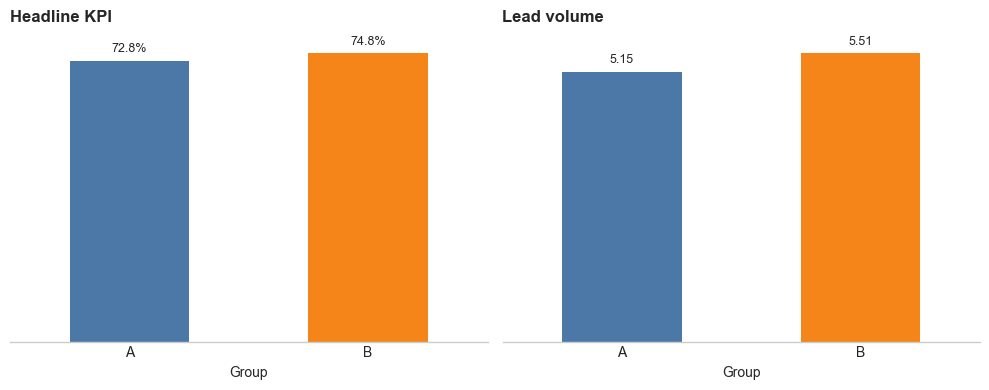

In [18]:
summary_metrics = outcomes.set_index("group")[["lead_rate", "avg_total_leads"]].rename(
    columns={"lead_rate": "Lead rate", "avg_total_leads": "Avg total leads"}
)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
summary_metrics["Lead rate"].plot(kind="bar", ax=axes[0], color=[PLOT_COLORS["A"], PLOT_COLORS["B"]])
finish_plot(axes[0], "Headline KPI", xlabel="Group", ylabel="Lead rate", percent_y=True)
add_bar_labels(axes[0], percent=True, decimals=1)
simplify_fully_labeled_bar_axis(axes[0])
summary_metrics["Avg total leads"].plot(kind="bar", ax=axes[1], color=[PLOT_COLORS["A"], PLOT_COLORS["B"]])
finish_plot(axes[1], "Lead volume", xlabel="Group", ylabel="Average total leads")
add_bar_labels(axes[1], decimals=2)
simplify_fully_labeled_bar_axis(axes[1])
for ax in axes:
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


The observed result is positive: B has more ads with leads and more total leads per ad.

I would present this as evidence in favor of the feature, but not as final causal proof. The data does not show the assignment process, and the balance checks show B differs from A on several car dimensions.

Recommended Next Steps:

1. Confirm randomization, exposure, and treatment label.
2. Review the 4.7% missing group rows.
3. Validate lead logging across A and B.
4. If setup checks pass, consider rollout or controlled ramp.
5. Monitor lead quality and seller/buyer guardrails.